# Assignment Sesi 11
Nama: Faraday Barr Fatahillah

Instruksi\
Anda adalah data analyst di sebuah jaringan restoran. Manajer operasional meminta laporan visual untuk memahami pola tip yang diberikan pelanggan, dengan tujuan merancang program insentif untuk staf pelayanan.\
Pertanyaan bisnis utama: Faktor apa saja yang paling berkaitan dengan jumlah tip yang tinggi?

In [102]:
#Import dataset
import pandas as pd
import seaborn as sns

In [103]:
df = sns.load_dataset('tips')

In [104]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [106]:
df['tip']

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [107]:
df['sex'].unique()

['Female', 'Male']
Categories (2, str): ['Male', 'Female']

In [108]:
df['smoker'].unique()

['No', 'Yes']
Categories (2, str): ['Yes', 'No']

In [109]:
df['day'].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

In [110]:
df['time'].unique()

['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

In [111]:
df['size'].unique()

array([2, 3, 4, 1, 6, 5])

**Task 1 — Distribusi tip**
1. Buat histogram kolom tip dengan bins=20. Tambahkan garis vertikal untuk nilai mean dan median menggunakan plt.axvline(). Beri label pada setiap garis. Tambahkan judul dan label axis.
2. Buat boxplot yang membandingkan distribusi tip berdasarkan hari (day). Urutkan hari secara logis: Thu, Fri, Sat, Sun. Tambahkan judul dan label axis.
3. Tulis di markdown: apakah distribusi tip terlihat normal atau skewed? Apakah ada hari tertentu yang punya outlier lebih banyak?

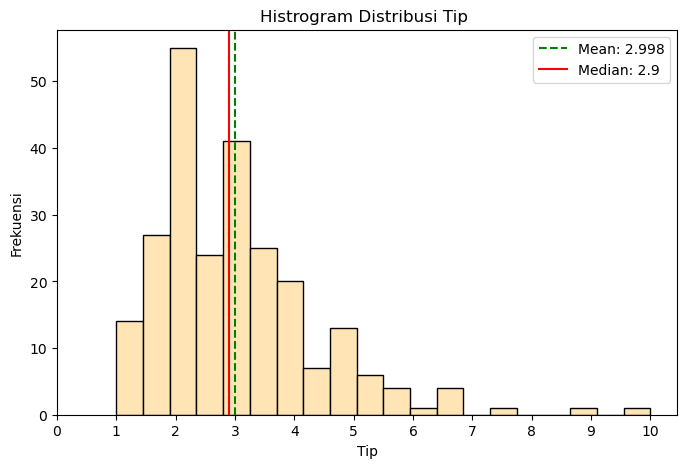

In [112]:
import matplotlib.pyplot as plt
import numpy as np

#Task 1.1
plt.figure(figsize=(8,5))
plt.hist(df['tip'], bins=20, edgecolor='black', color='moccasin')

# median val dan mean val
mean_val = df['tip'].mean()
median_val = df['tip'].median()

plt.axvline(mean_val, color='green', linestyle='--', label=f'Mean: {mean_val:.3f}')
plt.axvline(median_val, color='red', linestyle='-', label=f'Median: {median_val}')

# label
plt.title('Histrogram Distribusi Tip ')
plt.xlabel('Tip')
plt.ylabel('Frekuensi')
plt.xticks(np.arange(0, 11, 1))
plt.legend()

plt.show()



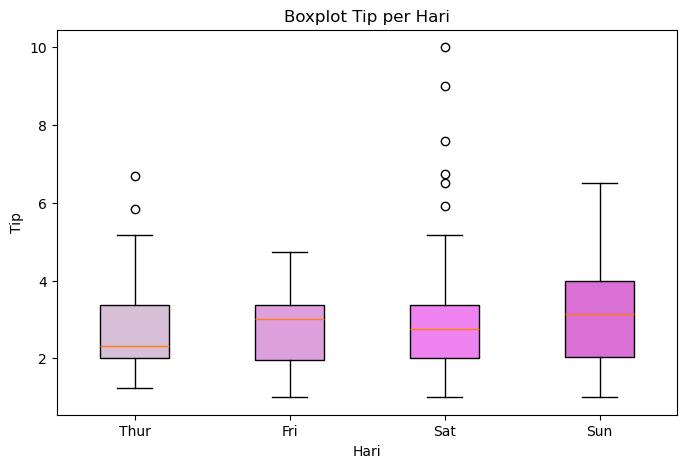

In [113]:
#Task 1.2
plt.figure(figsize=(8,5))

day_order = ['Thur', 'Fri', 'Sat', 'Sun']

data = [df[df['day'] == day]['tip'] for day in day_order]

colors = ['thistle', 'plum', 'violet', 'orchid'] 

bplot = plt.boxplot(data, label= day_order, patch_artist=True)
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(ticks=range(1, len(day_order) +1), labels=day_order)

plt.title('Boxplot Tip per Hari')
plt.xlabel('Hari')
plt.ylabel('Tip')

plt.show()

**#Task 1.3**\
Answer:\
Dari hasil dua plot di atas, dapat dilihat bahwa distribusi tip merupakan right skewed dengan besar tip yang diberikan pelanggan adalah sekitar 2 sampai 3 dollar. Selain itu, dapat dilihat bahwa nominal tip lebih besar saat akhir pekan dengan ukuran kotak dari boxplot lebih besar di hari sabtu dan minggu dibanding kamis atau jumat. Pada hari sabtu, banyak sekali outlier yang dapat dilihat dari boxplot karena banyak data yang diluar dari kotak yang sudah tergambarkan. Hal ini dapat menentukan bahwa pada hari sabtu pelanggan cenderung memberikan tip yang lebih besar.

**Task 2 — Hubungan antar variabel numerik**
1. Buat scatter plot antara total_bill (sumbu X) dan tip (sumbu Y). Beri warna berbeda berdasarkan kolom time (Lunch/Dinner). Tambahkan judul, label axis, dan legenda.
2. Hitung tip_pct = tip / total_bill * 100 dan tambahkan sebagai kolom baru di df. Buat scatter plot antara total_bill dan tip_pct. Apakah ada tren: pelanggan dengan tagihan lebih besar cenderung memberi tip persentase lebih tinggi atau lebih rendah?
3. Buat heatmap korelasi untuk kolom numerik (total_bill, tip, size, tip_pct) menggunakan sns.heatmap() dengan annot=True dan fmt='.2f'. Tambahkan judul.


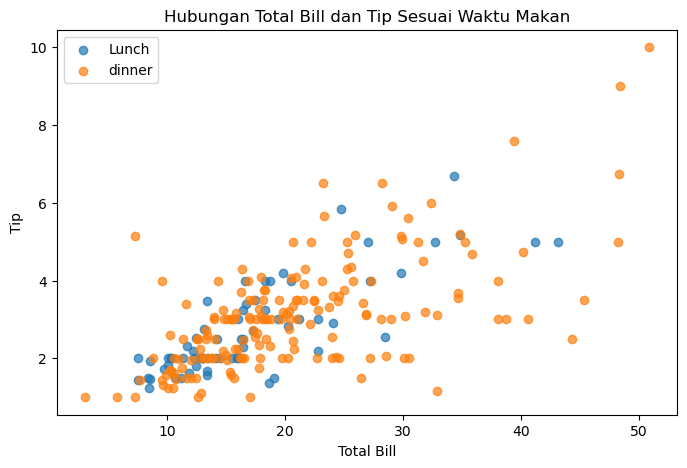

In [117]:
#Task 2.1
plt.figure(figsize=(8,5))

lunch = df[df['time'] == 'Lunch']
dinner = df[df['time'] == 'Dinner']

plt.scatter(lunch['total_bill'], lunch['tip'], label='Lunch', alpha=0.7)
plt.scatter(dinner['total_bill'], dinner['tip'], label='dinner', alpha=0.7)

plt.title('Hubungan Total Bill dan Tip Sesuai Waktu Makan')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()

plt.show()

In [ ]:
#Task 2.2
df['tip_pct'] = ((df['tip'] *100) / df['total_bill']).round(2)

df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


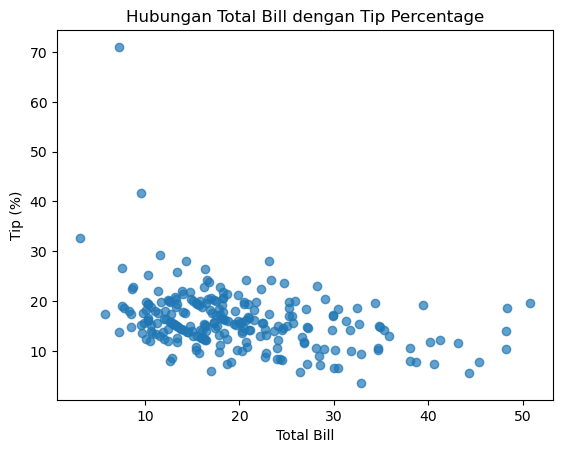

In [121]:
plt.scatter(df['total_bill'], df['tip_pct'], alpha=0.7)

plt.title('Hubungan Total Bill dengan Tip Percentage')
plt.xlabel('Total Bill')
plt.ylabel('Tip (%)')

plt.show()

<Axes: >

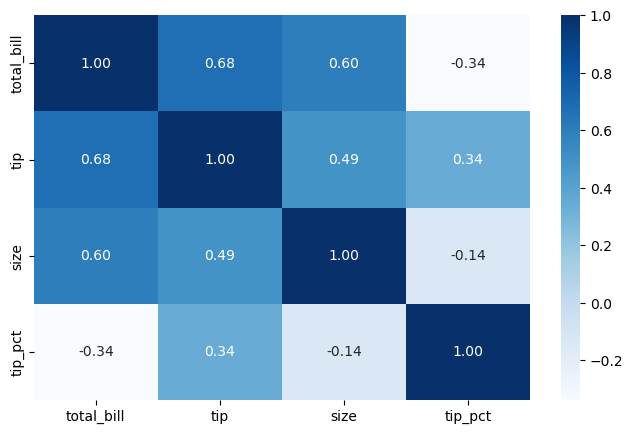

In [124]:
#Task 2.3
plt.figure(figsize=(8, 5))

cols = ['total_bill', 'tip', 'size', 'tip_pct']

corr = df[cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')

**Task 3 — Perbandingan antar kategori**
1. Buat bar chart rata-rata tip_pct berdasarkan kombinasi sex dan smoker. Gunakan sns.barplot() dengan hue. Tambahkan judul, label axis, dan legenda.
2. Buat satu figure dengan 2 subplot berdampingan:     - Kiri: boxplot tip berdasarkan smoker     - Kanan: boxplot tip berdasarkan sex     Beri suptitle yang menggambarkan isi figure.

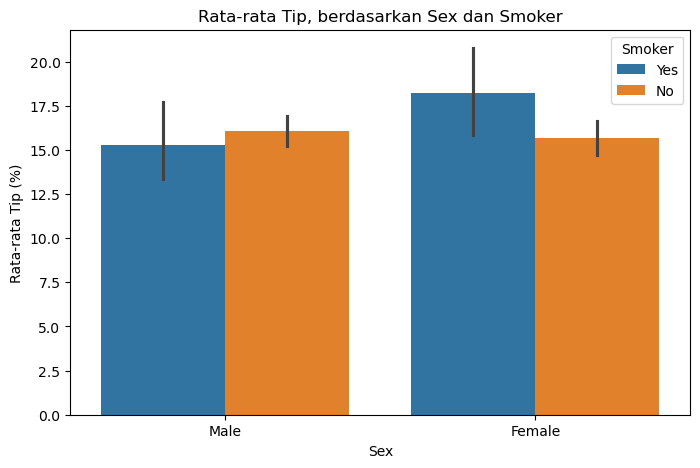

In [ ]:
#Task 3.1
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='sex', y = 'tip_pct', hue='smoker')

plt.title('Rata-rata Tip, berdasarkan Sex dan Smoker')
plt.xlabel('Sex')
plt.ylabel('Rata-rata Tip (%)')
plt.legend(title='Smoker')

plt.show()

C:\Users\bobe\AppData\Local\Temp\ipykernel_11280\1572649121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='tip', palette='BuGn')
C:\Users\bobe\AppData\Local\Temp\ipykernel_11280\1572649121.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='tip', palette='BuPu')


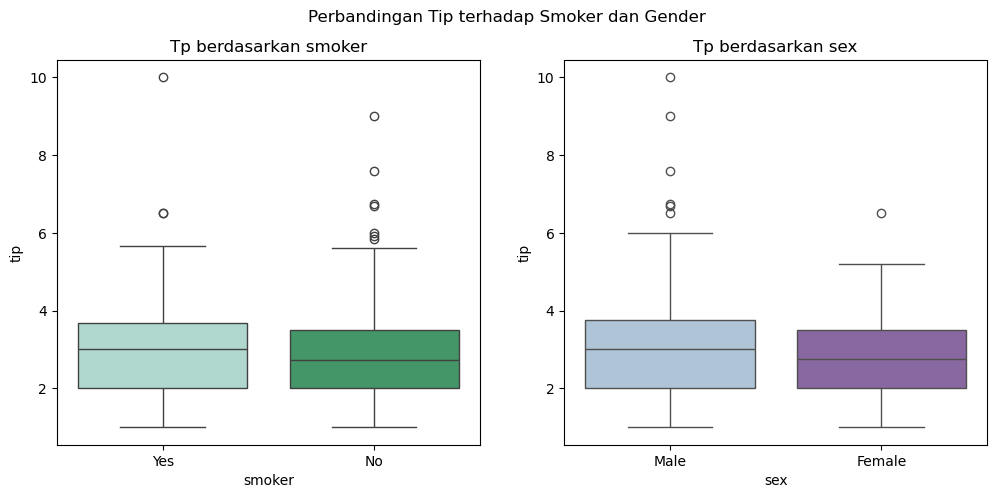

In [133]:
#Task 3.2
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='smoker', y='tip', palette='BuGn')
plt.title('Tp berdasarkan smoker')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='sex', y='tip', palette='BuPu')
plt.title('Tp berdasarkan sex')

plt.suptitle('Perbandingan Tip terhadap Smoker dan Gender')

plt.show()


**Task 4 — Narasi visual**\
Di cell markdown di akhir notebook, tulis ringkasan berisi:
1. Satu paragraf (3-5 kalimat) yang menjawab pertanyaan bisnis utama berdasarkan chart yang sudah dibuat. Sebutkan setidaknya dua faktor dan arahkan ke chart nomor berapa yang mendukung klaim tersebut.
2. Satu rekomendasi konkret untuk manajer operasional berdasarkan temuan Anda.

Answer:\

**#Task 4.1**\
Sesuai dengan grafik yang sudah ditampilkan, terdapat beberapa faktor yang membuat restoran ini mendapatkan tip dengan jumlah banyak. Faktor pertama adalah waktu, dapat dilihat bahwa akhir pekan cenderung lebih sering mendapatkan tip dan lebih variatif dibandingkan dengan hari lainnya. Faktor kedua yang lebih berpengaruh adalah hubungan antara total bill dengan tip. Grafik pada task 2 menceritakan bahwa pelanggan cenderung memberikan tip yang lebih kecil jika memiliki total bill yang lebih besar dan sebaliknya. Namun, hasil dari task 3 tidak memberikan alasan yang cukup kuat untuk memberikan kaitan antara besar tip dengan perokok atau gender.

**#Task 4.2**\
Salah satu rekomendasi yang dapat dilakukan untuk restoran ini adalah dengan memberikan pelayanan yang lebih berkualitas dan jumlah staf di akhir pekan. Hal ini dapat memaksimalkan kepuasan pelanggan dan pendapatan staf karena data menunjukkan tip cenderung lebih tinggi dan bervariasi.